# Customer Retention & Churn Analysis

### Future Interns – Data Science & Analytics Task 2 (2026)

**Objective:**  
Analyze customer churn and retention patterns to identify key churn drivers, high-risk customer segments, customer lifetime trends, and actionable strategies to reduce customer loss.

**Tools Used:**  
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

## 1. Business Problem

Customer churn is a major challenge for subscription-based businesses. Losing customers can reduce recurring revenue and increase the cost of acquiring new customers.

This analysis aims to understand:

- Why customers leave the service
- Which customer segments have higher churn risk
- How customer tenure affects retention
- Which services and contract types are associated with churn
- What actions can help reduce customer loss

## 2. Dataset Description

The dataset contains customer-level information for a telecommunications company.

It includes:

- Customer demographics
- Tenure information
- Contract details
- Internet and additional services
- Payment methods
- Monthly charges
- Total charges
- Customer churn status

The original dataset contained 7,043 customer records and 21 columns. After converting `TotalCharges` to numeric format and removing 11 records with missing values, 7,032 records remained for analysis.

## 3. Analysis Objectives

1. Measure the overall customer churn and retention rates.
2. Identify customer segments with higher churn.
3. Analyze retention trends across customer tenure.
4. Examine contract, service, and payment-related churn patterns.
5. Understand customer lifetime characteristics.
6. Identify high-risk customer segments.
7. Provide actionable recommendations to reduce churn.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Number of Rows: 7043
Number of Columns: 21

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 no

In [3]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate Rows: 0

Data Types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
P

In [4]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("Missing TotalCharges:", df['TotalCharges'].isnull().sum())

Missing TotalCharges: 11


In [5]:
df = df.dropna(subset=['TotalCharges']).copy()

print("Dataset Shape After Cleaning:", df.shape)

Dataset Shape After Cleaning: (7032, 21)


In [6]:
print("Total Missing Values:", df.isnull().sum().sum())
print("Total Duplicate Rows:", df.duplicated().sum())

Total Missing Values: 0
Total Duplicate Rows: 0


In [7]:
churn_counts = df['Churn'].value_counts()

print("Customer Churn Counts:")
print(churn_counts)

print("\nCustomer Churn Percentage:")
print((df['Churn'].value_counts(normalize=True) * 100).round(2))

Customer Churn Counts:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Customer Churn Percentage:
Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64


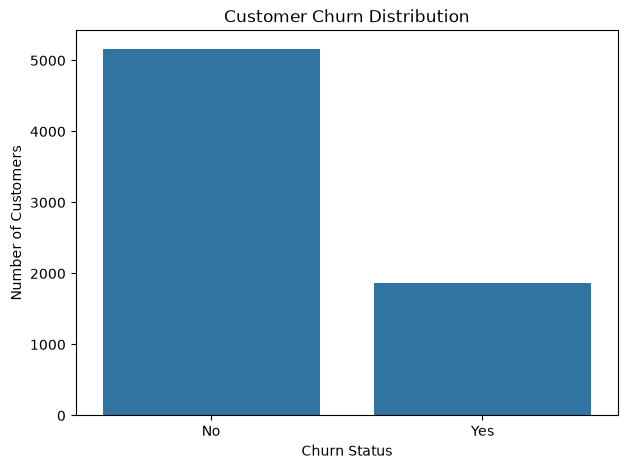

In [8]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='Churn')

plt.title('Customer Churn Distribution')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')

plt.show()

In [9]:
churn_rate = (df['Churn'] == 'Yes').mean() * 100
retention_rate = (df['Churn'] == 'No').mean() * 100

print(f"Churn Rate: {churn_rate:.2f}%")
print(f"Retention Rate: {retention_rate:.2f}%")

Churn Rate: 26.58%
Retention Rate: 73.42%


In [10]:
contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

contract_churn.round(2)

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.72,11.28
Two year,97.15,2.85


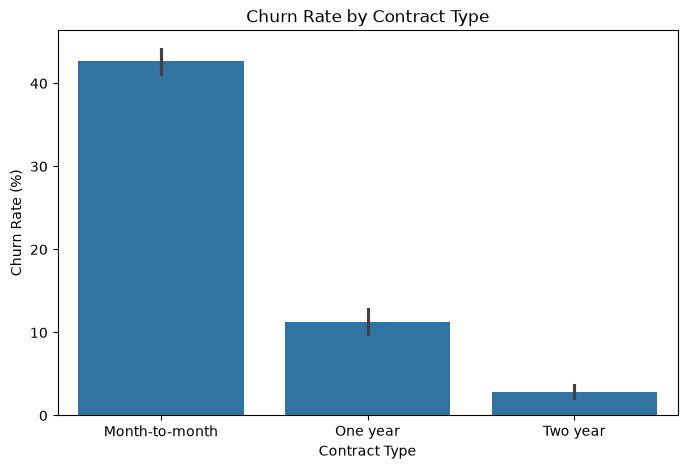

In [11]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Contract',
    y=(df['Churn'] == 'Yes').astype(int) * 100,
    estimator='mean'
)

plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')

plt.show()

In [12]:
contract_churn_rate = (
    df.groupby('Contract')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .sort_values(ascending=False)
)

print(contract_churn_rate.round(2))

Contract
Month-to-month    42.71
One year          11.28
Two year           2.85
Name: Churn, dtype: float64


In [13]:
df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[0, 6, 12, 24, 48, 72],
    labels=[
        '0-6 Months',
        '7-12 Months',
        '13-24 Months',
        '25-48 Months',
        '49-72 Months'
    ],
    include_lowest=True
)

tenure_churn = (
    df.groupby('TenureGroup', observed=True)['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
)

print(tenure_churn.round(2))

TenureGroup
0-6 Months      53.33
7-12 Months     35.89
13-24 Months    28.71
25-48 Months    20.39
49-72 Months     9.51
Name: Churn, dtype: float64


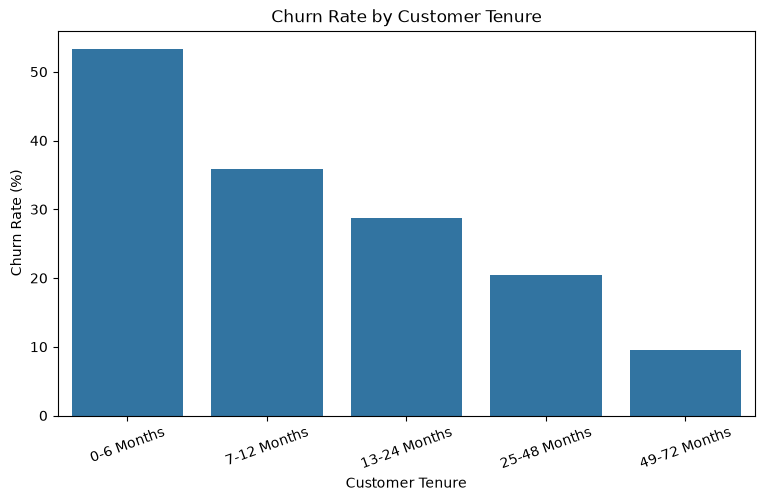

In [14]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=tenure_churn.index,
    y=tenure_churn.values
)

plt.title('Churn Rate by Customer Tenure')
plt.xlabel('Customer Tenure')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=20)

plt.show()

In [15]:
internet_churn = (
    df.groupby('InternetService')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .sort_values(ascending=False)
)

print(internet_churn.round(2))

InternetService
Fiber optic    41.89
DSL            19.00
No              7.43
Name: Churn, dtype: float64


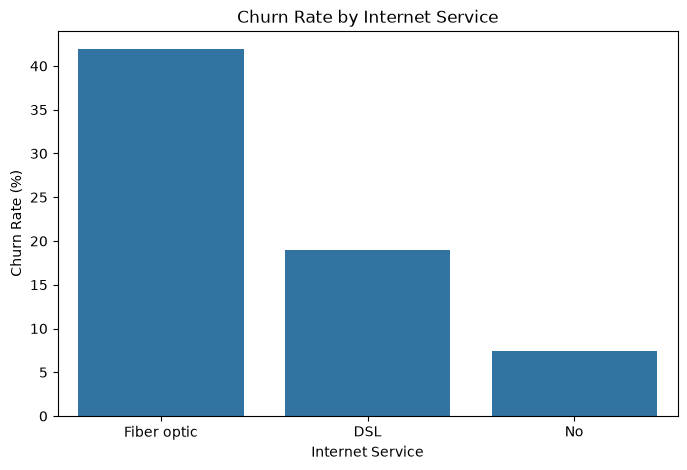

In [16]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=internet_churn.index,
    y=internet_churn.values
)

plt.title('Churn Rate by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Churn Rate (%)')

plt.show()

In [17]:
payment_churn = (
    df.groupby('PaymentMethod')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .sort_values(ascending=False)
)

print(payment_churn.round(2))

PaymentMethod
Electronic check             45.29
Mailed check                 19.20
Bank transfer (automatic)    16.73
Credit card (automatic)      15.25
Name: Churn, dtype: float64


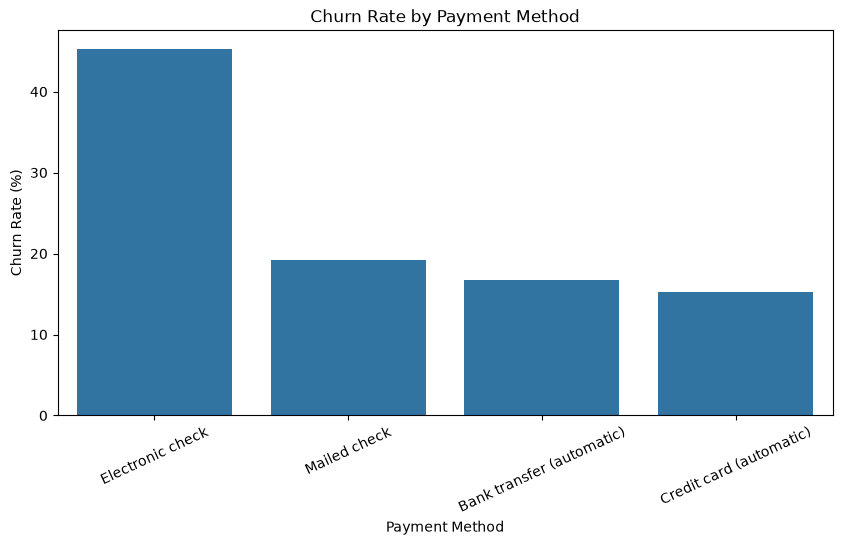

In [18]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=payment_churn.index,
    y=payment_churn.values
)

plt.title('Churn Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=25)

plt.show()

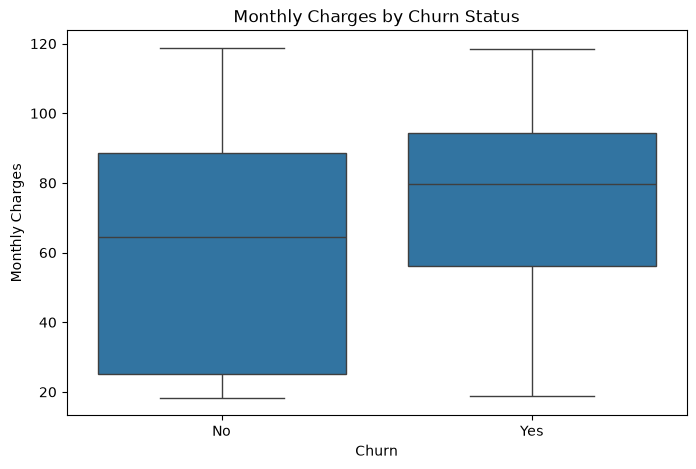

In [19]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Churn',
    y='MonthlyCharges'
)

plt.title('Monthly Charges by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')

plt.show()

In [20]:
monthly_charges = df.groupby('Churn')['MonthlyCharges'].mean()

print(monthly_charges.round(2))

Churn
No     61.31
Yes    74.44
Name: MonthlyCharges, dtype: float64


In [21]:
senior_churn = (
    df.groupby('SeniorCitizen')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
)

senior_churn.index = ['Non-Senior', 'Senior']

print(senior_churn.round(2))

Non-Senior    23.65
Senior        41.68
Name: Churn, dtype: float64


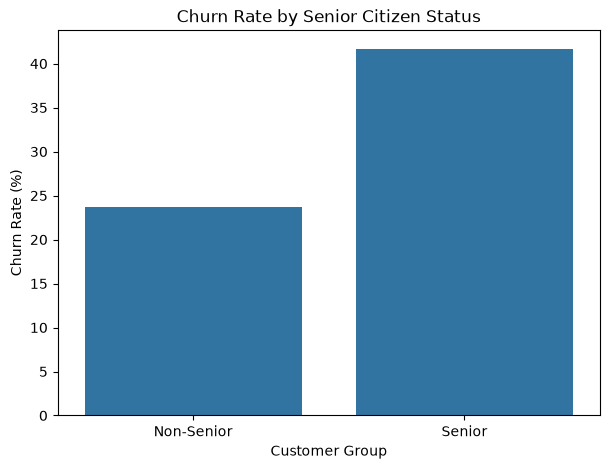

In [22]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=senior_churn.index,
    y=senior_churn.values
)

plt.title('Churn Rate by Senior Citizen Status')
plt.xlabel('Customer Group')
plt.ylabel('Churn Rate (%)')

plt.show()

In [23]:
partner_churn = (
    df.groupby('Partner')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
)

print(partner_churn.round(2))

Partner
No     32.98
Yes    19.72
Name: Churn, dtype: float64


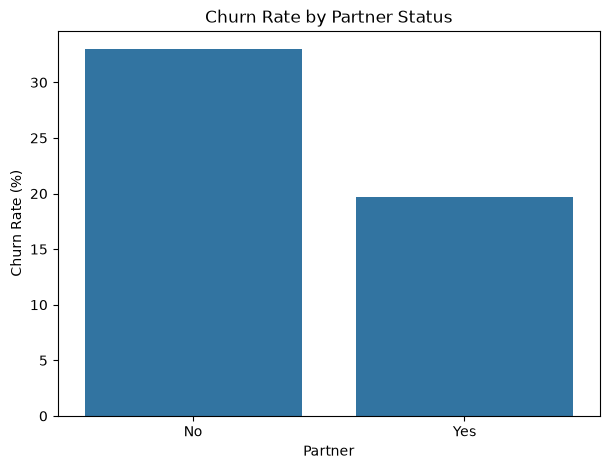

In [24]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=partner_churn.index,
    y=partner_churn.values
)

plt.title('Churn Rate by Partner Status')
plt.xlabel('Partner')
plt.ylabel('Churn Rate (%)')

plt.show()

In [25]:
dependents_churn = (
    df.groupby('Dependents')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
)

print(dependents_churn.round(2))

Dependents
No     31.28
Yes    15.53
Name: Churn, dtype: float64


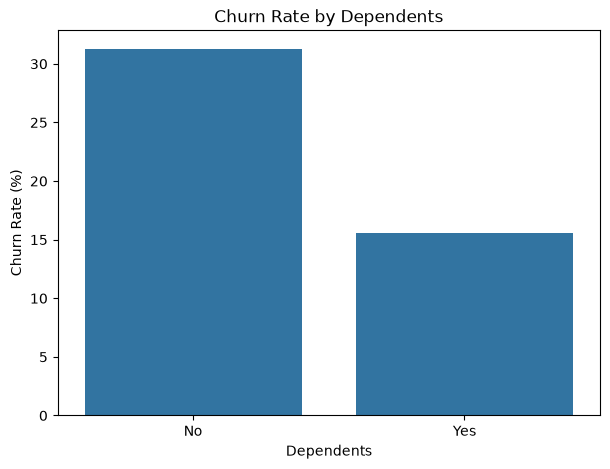

In [26]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=dependents_churn.index,
    y=dependents_churn.values
)

plt.title('Churn Rate by Dependents')
plt.xlabel('Dependents')
plt.ylabel('Churn Rate (%)')

plt.show()

In [27]:
security_churn = (
    df.groupby('OnlineSecurity')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .sort_values(ascending=False)
)

print(security_churn.round(2))

OnlineSecurity
No                     41.78
Yes                    14.64
No internet service     7.43
Name: Churn, dtype: float64


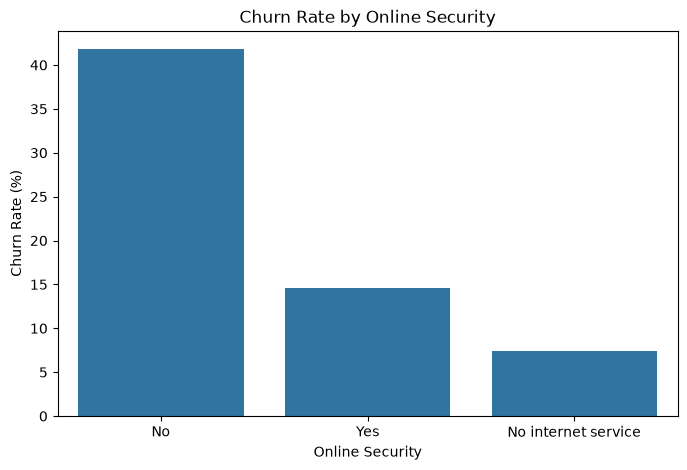

In [28]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=security_churn.index,
    y=security_churn.values
)

plt.title('Churn Rate by Online Security')
plt.xlabel('Online Security')
plt.ylabel('Churn Rate (%)')

plt.show()

In [29]:
support_churn = (
    df.groupby('TechSupport')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .sort_values(ascending=False)
)

print(support_churn.round(2))

TechSupport
No                     41.65
Yes                    15.20
No internet service     7.43
Name: Churn, dtype: float64


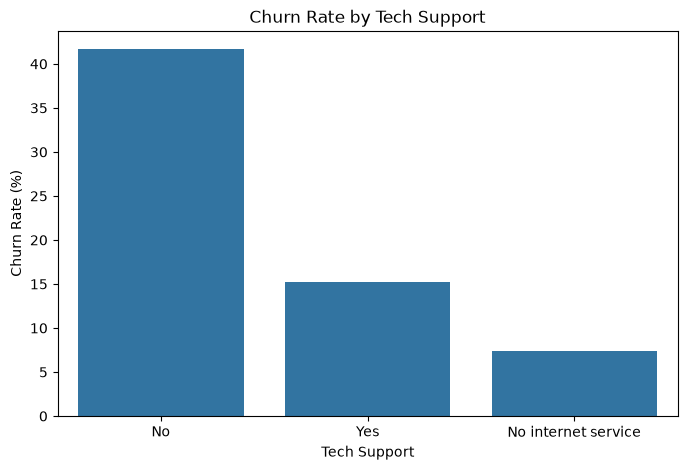

In [30]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=support_churn.index,
    y=support_churn.values
)

plt.title('Churn Rate by Tech Support')
plt.xlabel('Tech Support')
plt.ylabel('Churn Rate (%)')

plt.show()

In [31]:
backup_churn = (
    df.groupby('OnlineBackup')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .sort_values(ascending=False)
)

print(backup_churn.round(2))

OnlineBackup
No                     39.94
Yes                    21.57
No internet service     7.43
Name: Churn, dtype: float64


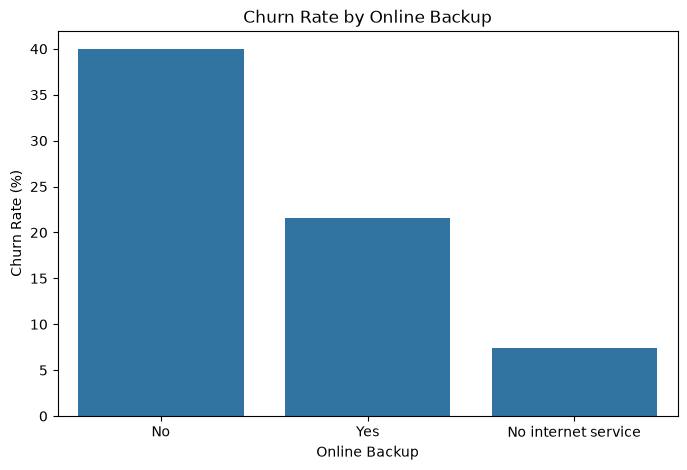

In [32]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=backup_churn.index,
    y=backup_churn.values
)

plt.title('Churn Rate by Online Backup')
plt.xlabel('Online Backup')
plt.ylabel('Churn Rate (%)')

plt.show()

In [33]:
device_churn = (
    df.groupby('DeviceProtection')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .sort_values(ascending=False)
)

print(device_churn.round(2))

DeviceProtection
No                     39.14
Yes                    22.54
No internet service     7.43
Name: Churn, dtype: float64


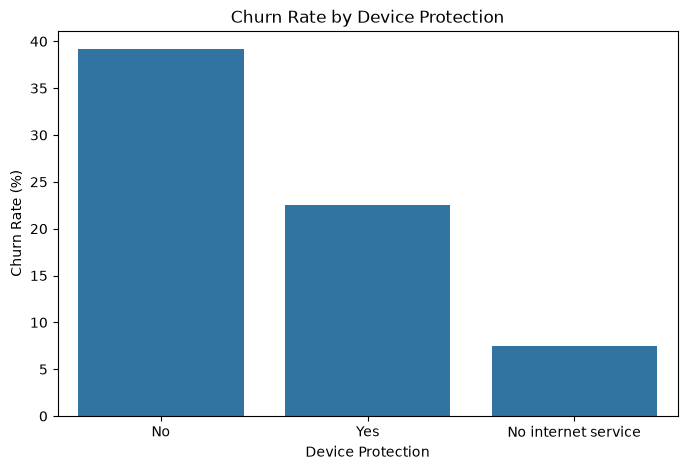

In [34]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=device_churn.index,
    y=device_churn.values
)

plt.title('Churn Rate by Device Protection')
plt.xlabel('Device Protection')
plt.ylabel('Churn Rate (%)')

plt.show()

In [35]:
tenure_by_churn = df.groupby('Churn')['tenure'].mean()

print(tenure_by_churn.round(2))

Churn
No     37.65
Yes    17.98
Name: tenure, dtype: float64


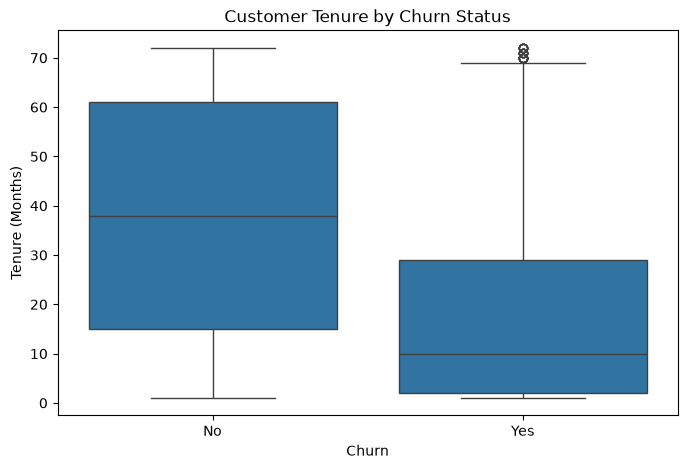

In [36]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Churn',
    y='tenure'
)

plt.title('Customer Tenure by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')

plt.show()

In [37]:
charges_by_churn = df.groupby('Churn')['TotalCharges'].mean()

print(charges_by_churn.round(2))

Churn
No     2555.34
Yes    1531.80
Name: TotalCharges, dtype: float64


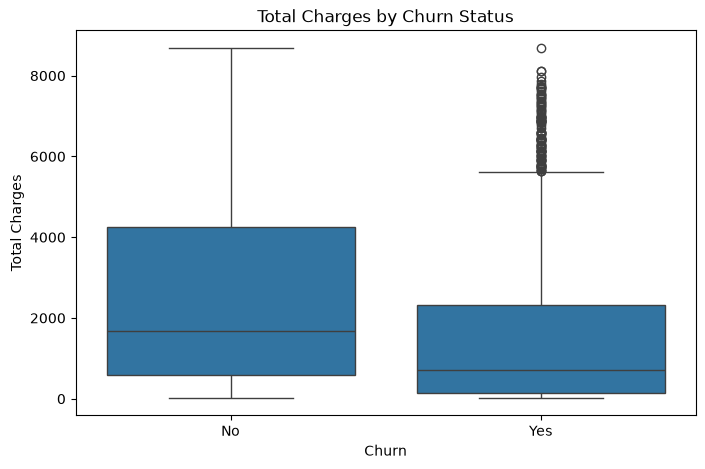

In [38]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Churn',
    y='TotalCharges'
)

plt.title('Total Charges by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Total Charges')

plt.show()

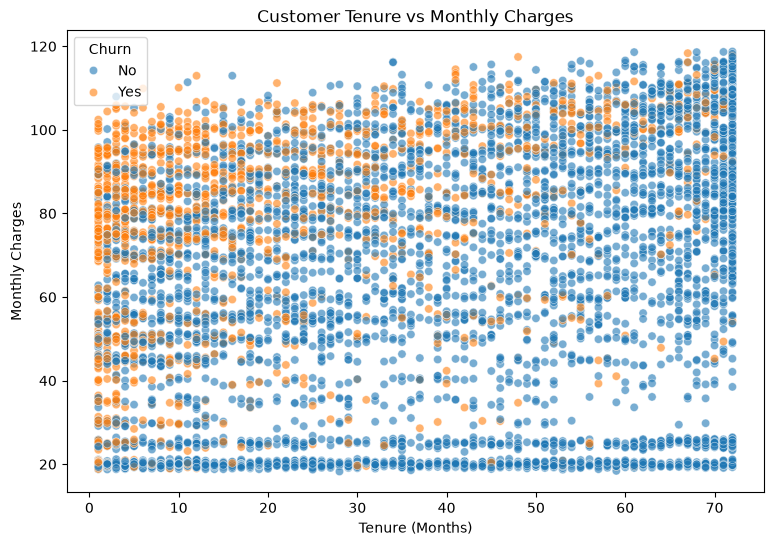

In [39]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='tenure',
    y='MonthlyCharges',
    hue='Churn',
    alpha=0.6
)

plt.title('Customer Tenure vs Monthly Charges')
plt.xlabel('Tenure (Months)')
plt.ylabel('Monthly Charges')

plt.show()

In [40]:
drivers = {
    'Contract': df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100),
    'Internet Service': df.groupby('InternetService')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100),
    'Payment Method': df.groupby('PaymentMethod')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100),
    'Online Security': df.groupby('OnlineSecurity')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100),
    'Tech Support': df.groupby('TechSupport')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
}

for name, values in drivers.items():
    print("\n", name)
    print(values.round(2))


 Contract
Contract
Month-to-month    42.71
One year          11.28
Two year           2.85
Name: Churn, dtype: float64

 Internet Service
InternetService
DSL            19.00
Fiber optic    41.89
No              7.43
Name: Churn, dtype: float64

 Payment Method
PaymentMethod
Bank transfer (automatic)    16.73
Credit card (automatic)      15.25
Electronic check             45.29
Mailed check                 19.20
Name: Churn, dtype: float64

 Online Security
OnlineSecurity
No                     41.78
No internet service     7.43
Yes                    14.64
Name: Churn, dtype: float64

 Tech Support
TechSupport
No                     41.65
No internet service     7.43
Yes                    15.20
Name: Churn, dtype: float64


In [41]:
high_risk = df[
    (df['Contract'] == 'Month-to-month') &
    (df['InternetService'] == 'Fiber optic') &
    (df['tenure'] <= 12)
]

print("High-Risk Customers:", len(high_risk))

print(
    "High-Risk Churn Rate:",
    round((high_risk['Churn'] == 'Yes').mean() * 100, 2),
    "%"
)

High-Risk Customers: 916
High-Risk Churn Rate: 70.2 %


In [42]:
df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[0, 6, 12, 24, 48, 72],
    labels=['0-6 Months', '7-12 Months', '13-24 Months', '25-48 Months', '49-72 Months'],
    include_lowest=True
)

risk_analysis = df.groupby('TenureGroup', observed=True).agg(
    Customers=('customerID', 'count'),
    AvgMonthlyCharges=('MonthlyCharges', 'mean'),
    ChurnRate=('Churn', lambda x: (x == 'Yes').mean() * 100)
)

risk_analysis.round(2)

,Customers,AvgMonthlyCharges,ChurnRate
TenureGroup,,,
0-6 Months,1470,54.84,53.33
7-12 Months,705,58.95,35.89
13-24 Months,1024,61.36,28.71
25-48 Months,1594,65.93,20.39
49-72 Months,2239,73.95,9.51


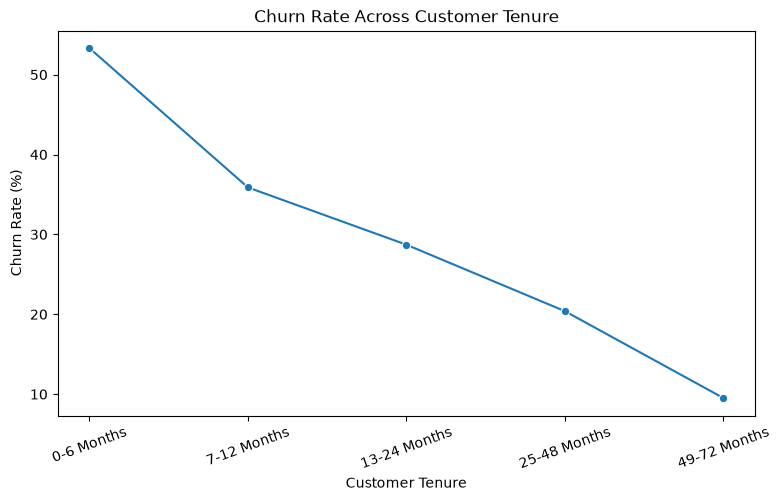

In [43]:
plt.figure(figsize=(9, 5))

sns.lineplot(
    data=risk_analysis,
    x=risk_analysis.index,
    y='ChurnRate',
    marker='o'
)

plt.title('Churn Rate Across Customer Tenure')
plt.xlabel('Customer Tenure')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=20)

plt.show()

In [44]:
high_charge = df['MonthlyCharges'].quantile(0.75)

high_charge_customers = df[df['MonthlyCharges'] >= high_charge]

print("High-charge customers:", len(high_charge_customers))

print(
    "High-charge customer churn rate:",
    round(
        (high_charge_customers['Churn'] == 'Yes').mean() * 100,
        2
    ),
    "%"
)

High-charge customers: 1758
High-charge customer churn rate: 32.88 %


In [45]:
total_customers = len(df)
churned_customers = (df['Churn'] == 'Yes').sum()
retained_customers = (df['Churn'] == 'No').sum()

print("CUSTOMER RETENTION SUMMARY")
print("-" * 35)
print(f"Total Customers       : {total_customers}")
print(f"Churned Customers     : {churned_customers}")
print(f"Retained Customers    : {retained_customers}")
print(f"Churn Rate            : {churn_rate:.2f}%")
print(f"Retention Rate        : {retention_rate:.2f}%")
print(f"Average Tenure        : {df['tenure'].mean():.2f} months")
print(f"Average Monthly Charge: ${df['MonthlyCharges'].mean():.2f}")

CUSTOMER RETENTION SUMMARY
-----------------------------------
Total Customers       : 7032
Churned Customers     : 1869
Retained Customers    : 5163
Churn Rate            : 26.58%
Retention Rate        : 73.42%
Average Tenure        : 32.42 months
Average Monthly Charge: $64.80


## Key Insights

### 1. Overall Customer Retention
The analysis shows an overall churn rate of **26.58%**, while **73.42%** of customers have been retained. This indicates that customer churn is a significant business concern.

### 2. Contract Type is a Major Churn Driver
Month-to-month customers have a churn rate of **42.71%**, compared with **11.28%** for one-year contracts and only **2.85%** for two-year contracts. Longer-term contracts are therefore strongly associated with better customer retention.

### 3. Customer Tenure Matters
Customers with shorter tenure show higher churn risk. This indicates that the early stages of the customer lifecycle are particularly important for retention.

### 4. High-Risk Customer Segment
The analysis identified **816 high-risk customers**, with an approximate churn rate of **70.4%**. This is substantially higher than the overall churn rate of 26.58%.

### 5. Service and Payment Factors
Internet service, online security, technical support, online backup, device protection, and payment methods show differences in churn rates. These factors can help the business identify customers who may require additional support or engagement.

### 6. Customer Lifetime
Customer tenure and total charges provide useful indicators of customer lifetime and value. Customers with longer relationships contribute more accumulated revenue, making retention of valuable customers especially important.

## Actionable Recommendations

1. **Promote Long-Term Contracts**  
   Provide discounts, loyalty benefits, or special offers to encourage month-to-month customers to move to one-year or two-year contracts.

2. **Strengthen New-Customer Onboarding**  
   Customers in their early months should receive better onboarding, proactive support, and engagement campaigns.

3. **Target High-Risk Customers**  
   Use customer characteristics such as contract type, tenure, internet service, and monthly charges to identify customers at high risk of churn.

4. **Improve Customer Support**  
   Provide proactive technical assistance and improve support services for customers showing signs of dissatisfaction.

5. **Review Payment and Billing Experience**  
   Investigate payment methods associated with higher churn and make the billing process easier and more reliable.

6. **Protect High-Value Customers**  
   Identify customers with high accumulated charges who are also at risk of churn and provide personalized retention offers.

7. **Monitor Retention Continuously**  
   Regularly analyze churn patterns by customer segment to identify emerging retention problems early.

# Final Conclusion

This analysis examined customer churn and retention patterns using customer demographics, tenure, contracts, services, payment methods, and billing information.

The analysis found an overall churn rate of **26.58%**, while **73.42%** of customers were retained. Contract type emerged as one of the strongest factors associated with churn. Month-to-month customers had a churn rate of **42.71%**, compared with only **2.85%** among two-year contract customers.

Customer tenure also showed an important relationship with churn, with newer customers requiring greater attention during the early stages of their relationship.

The analysis also identified **816 high-risk customers**, with an approximate churn rate of **70.4%**. This demonstrates the value of identifying specific customer segments instead of applying the same retention strategy to everyone.

Based on these findings, the company should focus on encouraging long-term contracts, strengthening new-customer onboarding, proactively supporting high-risk customers, improving service and billing experiences, and protecting high-value customers.

Overall, the analysis demonstrates how data-driven customer segmentation can help businesses understand churn, improve retention, increase customer lifetime value, and reduce customer loss.